# 03. Phase Diagram

Dynamical regimes of the circuit when parameters are changed by large amounts (Fig. 6F). Non-dimensionalising with $\tilde x = (a/d)X$, $\tilde y = (b/d)Y$, $\tilde t = dt$ leaves

$$\frac{d\tilde x}{d\tilde t} = \tilde x\left[\tilde x\left(1 - \frac{\tilde x}{p_1}\right) - \tilde y - 1\right], \qquad \frac{d\tilde y}{d\tilde t} = \tilde y\left[p_2 \tilde x - p_3\right]$$

with $p_1 = ca/d$ (self-activation strength), $p_2 = f/a$ (inhibitor induction strength) and $p_3 = g/d = 1$.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add package source to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
# DynamicModel_Package lives in the repository's libs/ directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'libs')))

FIGURE_DIR = os.path.abspath(os.path.join(os.getcwd(), '../figures'))
RESULT_DIR = os.path.abspath(os.path.join(os.getcwd(), '../data/results'))
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

from circuit_to_target.model import integrate
from circuit_to_target.phase_diagram import (P1_CRITICAL, bistable_boundary,
                                             classify_regime,
                                             dimensionless_groups,
                                             plot_phase_diagram, x_plus)

## Regime boundaries

The non-trivial $\tilde x$ nullcline meets the axis at $X_\pm = [p_1 \pm \sqrt{p_1(p_1-4)}]/2$, real only for $p_1 \ge 4$. $(X_+, 0)$ is stable along $\tilde x$; along $\tilde y$ its Jacobian entry is $p_2 X_+ - p_3$, so it is a second attractor exactly when $p_2 X_+ < 1$. Hence the circuit is bistable below $p_2 = 1/X_+$ and excitable above it.

In [2]:
for p1 in [3.0, 5.0, 10.0, 50.0]:
    print(f"p1 = {p1:5g}:  X+ = {float(x_plus(p1)):8.4f}   "
          f"boundary p2 = 1/X+ = {float(bistable_boundary(p1)):.4f}")

p1 =     3:  X+ =      nan   boundary p2 = 1/X+ = nan
p1 =     5:  X+ =   3.6180   boundary p2 = 1/X+ = 0.2764
p1 =    10:  X+ =   8.8730   boundary p2 = 1/X+ = 0.1127
p1 =    50:  X+ =  48.9792   boundary p2 = 1/X+ = 0.0204


## Verify the classification against direct integration

For each $(p_1, p_2)$ we rebuild a dimensional parameter set, start just below $(X_+, 0)$ and integrate the full circuit. In the bistable regime the trajectory stays at $X_+$; in the excitable regime it returns to the origin.

In [3]:
def dimensional(p1, p2, p3=1.0, a=1.0, b=1.0, d=1.0):
    """A parameter set realising the given dimensionless groups."""
    return {'a': a, 'b': b, 'c': p1 * d / a, 'd': d, 'f': p2 * a, 'g': p3 * d}


rows = []
for p1, p2 in [(3.0, 0.5), (3.0, 5.0), (10.0, 0.05), (10.0, 1.0), (50.0, 0.01), (50.0, 2.0)]:
    pars = dimensional(p1, p2)
    assert np.allclose(dimensionless_groups(pars)['p1'], p1)
    assert np.allclose(dimensionless_groups(pars)['p2'], p2)

    start = 1.0 if p1 < P1_CRITICAL else float(x_plus(p1)) * 0.999
    traj = integrate(start, 1e-3, pars, 200.0, dt=1e-3)
    x_end = traj['x'].values[-1]
    rows.append({'p1': p1, 'p2': p2, 'regime': classify_regime(p1, p2),
                 'x_end': round(float(x_end), 4),
                 'settles': 'ON' if x_end > 1 else 'OFF'})

verification = pd.DataFrame(rows)
print(verification.to_string(index=False))

expected = {'monostable_off': 'OFF', 'bistable': 'ON', 'excitable': 'OFF'}
assert all(expected[r['regime']] == r['settles'] for _, r in verification.iterrows())
print("\nclassification agrees with direct integration")

  p1   p2         regime   x_end settles
 3.0 0.50 monostable_off  0.0000     OFF
 3.0 5.00 monostable_off  0.0000     OFF
10.0 0.05       bistable  8.8730      ON
10.0 1.00      excitable  0.0000     OFF
50.0 0.01       bistable 48.9792      ON
50.0 2.00      excitable  0.0000     OFF

classification agrees with direct integration


## Fig. 6F - phase diagram

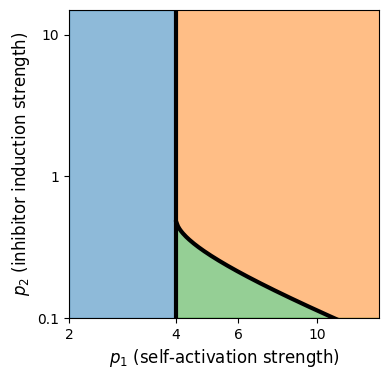

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_phase_diagram(ax)
fig.savefig(os.path.join(FIGURE_DIR, 'phase_diagram.png'), dpi=600, bbox_inches='tight')
fig.savefig(os.path.join(FIGURE_DIR, 'phase_diagram.pdf'), dpi=600, bbox_inches='tight')

## Representative trajectory per regime

One dimensionless trajectory in each of the three regimes, as in the insets of Fig. 6F.

off        p1=2     p2=0.1   -> monostable_off
excitable  p1=10    p2=0.5   -> excitable
bistable   p1=5     p2=0.2   -> bistable


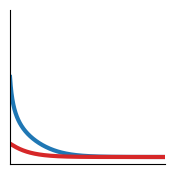

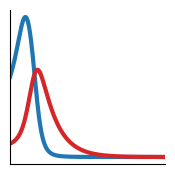

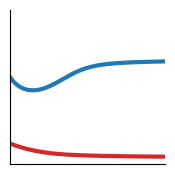

In [5]:
regimes = {
    'off':       {'p1': 2.0,  'p2': 0.1},
    'excitable': {'p1': 10.0, 'p2': 0.5},
    'bistable':  {'p1': 5.0,  'p2': 0.2},
}

trajectories = {}
for name, groups in regimes.items():
    pars = dimensional(groups['p1'], groups['p2'])
    trajectories[name] = integrate(3.0, 0.5, pars, 10.0, dt=1e-3)
    print(f"{name:10s} p1={groups['p1']:<5g} p2={groups['p2']:<5g} "
          f"-> {classify_regime(groups['p1'], groups['p2'])}")

y_min = min(t[['x', 'y']].values.min() for t in trajectories.values())
y_max = max(t[['x', 'y']].values.max() for t in trajectories.values())
margin = 0.05 * (y_max - y_min)

for name, traj in trajectories.items():
    fig, ax = plt.subplots(figsize=(2, 2))
    ax.plot(traj['t'], traj['x'], color='tab:blue', lw=3)
    ax.plot(traj['t'], traj['y'], color='tab:red', lw=3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_xlim(left=0, right=traj['t'].max())
    fig.savefig(os.path.join(FIGURE_DIR, f'dynamics_{name}.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(FIGURE_DIR, f'dynamics_{name}.png'), dpi=600, bbox_inches='tight')